In [1]:
import numpy as np
import pandas as pd
import time
import pulp

# ==========================================
# 1. DATA GENERATION
# ==========================================


def generate_deadline_bin_packing_data(n_items, capacity):
    np.random.seed(42)
    
    # ==========================================
    # 1. Standard Random Distributions
    # ==========================================
    arrival_times = np.sort(np.random.randint(0, 50, n_items))
    deadlines = arrival_times + np.random.randint(20, 100, n_items)
    
    s1 = np.random.normal(capacity * 0.2, 5, n_items // 2)
    s2 = np.random.normal(capacity * 0.7, 5, n_items // 2)
    
    distributions = {
        'uniform': np.random.randint(1, capacity, n_items),
        'bimodal': np.clip(np.concatenate([s1, s2]), 1, capacity - 1),
        'skewed': (np.random.beta(a=1, b=5, size=n_items) * capacity).clip(1, capacity - 1),
        'tight': np.random.randint(capacity * 0.4, capacity * 0.6, n_items),
        'loose': np.random.randint(1, capacity * 0.2, n_items)
    }
    
    dataset = {}
    for dist_name, sizes in distributions.items():
        df = pd.DataFrame({
            'item_id': range(n_items),
            'size': sizes.astype(int),
            'arrival_time': arrival_times,
            'deadline': deadlines
        })
        dataset[dist_name] = df
        
    # ==========================================
    # 2. Adversarial Dataset (FF vs DABF)
    # ==========================================
    # We repeat the sequence [50, 70, 20, 40] to continuously trick FF.
    adv_sizes = []
    for _ in range(n_items // 4):
        adv_sizes.extend([50, 70, 20, 40])
        
    # Pad the remainder if n_items is not a perfect multiple of 4
    if n_items % 4 != 0:
        adv_sizes.extend([50, 70, 20, 40][:n_items % 4])
        
    adv_df = pd.DataFrame({
        'item_id': range(n_items),
        'size': adv_sizes,
        # Set arrivals to 0 to remove temporal interference and isolate spatial logic
        'arrival_time': np.zeros(n_items, dtype=int), 
        # Strictly increasing deadlines guarantee the algorithms sort and 
        # process the items in the exact adversarial order we built above.
        'deadline': np.arange(10, 10 + n_items * 10, 10) 
    })
    
    dataset['interleaved'] = adv_df
        
    return dataset

# ==========================================
# HELPER FUNCTION TO CALCULATE WASTE RATE
# ==========================================
def calculate_waste_rate(bins, df, capacity):
    """
    Calculates the proportion of total bin capacity that remains unused.
    Waste Rate = (Total Provisioned Capacity - Total Used Capacity) / Total Provisioned Capacity
    """
    if not bins:
        return 0.0  # If no bins were opened, no capacity was wasted
        
    # Total capacity is the number of bins opened multiplied by the capacity per bin
    total_capacity = len(bins) * capacity
    
    # Map item IDs to their sizes
    sizes = df.set_index('item_id')['size'].to_dict()
    
    used_capacity = 0
    for b in bins:
        bin_items = b.get('items', [])
        # Sum the sizes of all items placed in this bin
        used_capacity += sum(sizes[i] for i in bin_items)
            
    # The waste rate is the fraction of the total capacity that is empty
    waste_rate = (total_capacity - used_capacity) / total_capacity
    
    return waste_rate

# ==========================================
# 2. ILP SOLVER 
# ==========================================
def solve_deadline_bin_packing(df, capacity=100, time_limit=60):
    items = df['item_id'].tolist()
    bins = items.copy() # Max possible bins is the number of items
    
    sizes = df.set_index('item_id')['size'].to_dict()
    arrivals = df.set_index('item_id')['arrival_time'].to_dict()
    deadlines = df.set_index('item_id')['deadline'].to_dict()
    
    M = df['deadline'].max() # Big-M for logic constraints
    
    # Initialize Problem
    prob = pulp.LpProblem("Deadline_Bin_Packing", pulp.LpMinimize)
    
    # Decision Variables
    y = pulp.LpVariable.dicts("y", bins, cat=pulp.LpBinary)
    x = pulp.LpVariable.dicts("x", (items, bins), cat=pulp.LpBinary)
    t = pulp.LpVariable.dicts("t", bins, lowBound=0, cat=pulp.LpInteger)
    
    # Objective: Minimize number of active bins
    prob += pulp.lpSum([y[j] for j in bins])
    
    # Constraints
    # 1. Every item in exactly one bin
    for i in items:
        prob += pulp.lpSum([x[i][j] for j in bins]) == 1
        
    # 2. Bin capacity
    for j in bins:
        prob += pulp.lpSum([sizes[i] * x[i][j] for i in items]) <= capacity * y[j]
        
    # 3. Time window constraints
    for j in bins:
        for i in items:
            # Dispatch must be >= arrival time of all items in the bin
            prob += t[j] >= arrivals[i] * x[i][j]
            # Dispatch must be <= deadline of all items in the bin
            prob += t[j] <= deadlines[i] + M * (1 - x[i][j])
            
    # 4. Symmetry Breaking (Forces solver to fill bins in order j=0, 1, 2...)
    for j in range(len(bins) - 1):
        prob += y[j] >= y[j+1]

    # Solve the problem (Setting a time limit as Bin Packing is NP-Hard)
    solver = pulp.PULP_CBC_CMD(timeLimit=time_limit, msg=False)
    prob.solve(solver)
    
    # Extract results
    status = pulp.LpStatus[prob.status]
    
    used_bins = []
    if status in ['Optimal', 'Not Solved']: 
        for j in bins:
            if pulp.value(y[j]) > 0.5:
                bin_items = [i for i in items if pulp.value(x[i][j]) > 0.5]
                used_bins.append({
                    'bin_id': j,
                    'items': bin_items,
                    'total_size': sum(sizes[i] for i in bin_items),
                    'dispatch_time': pulp.value(t[j])
                })
                
    return used_bins

# ==========================================
# 3. BIN PACKING ALGORITHMS
# ==========================================


# 2. Deadline-Aware First Fit
def ffdd_offline(df_items, capacity):
    sorted_items = df_items.sort_values(by=['deadline', 'size'], ascending=[True, False]).to_dict('records')
    bins = []
    for item in sorted_items:
        placed = False
        for b in bins:
            temporal_valid = item['arrival_time'] <= b['earliest_deadline']
            if b['remaining_capacity'] >= item['size'] and temporal_valid:
                b['items'].append(item['item_id'])
                b['remaining_capacity'] -= item['size']
                b['earliest_deadline'] = min(b['earliest_deadline'], item['deadline'])
                placed = True
                break
        if not placed:
            bins.append({
                'items': [item['item_id']],
                'remaining_capacity': capacity - item['size'],
                'earliest_deadline': item['deadline']
            })
    return bins

# 3. Deadline-Aware Next Fit (Online)
def next_fit_online(df_items, capacity):
    stream_items = df_items.sort_values(by=['arrival_time']).to_dict('records')
    bins = []
    for item in stream_items:
        placed = False
        if bins:
            current_bin = bins[-1]
            if current_bin['remaining_capacity'] >= item['size'] and item['arrival_time'] <= current_bin['earliest_deadline']:
                current_bin['items'].append(item['item_id'])
                current_bin['remaining_capacity'] -= item['size']
                current_bin['earliest_deadline'] = min(current_bin['earliest_deadline'], item['deadline'])
                placed = True
        if not placed:
            bins.append({
                'items': [item['item_id']],
                'remaining_capacity': capacity - item['size'],
                'earliest_deadline': item['deadline']
            })
    return bins

# 4. NEW: Deadline-Aware Best Fit (DABF)
def deadline_aware_best_fit(df_items, capacity):
    sorted_items = df_items.sort_values(by=['deadline', 'size'], ascending=[True, False]).to_dict('records')
    bins = []
    
    for item in sorted_items:
        best_bin_idx = -1
        min_remaining_space = float('inf')
        
        for i, b in enumerate(bins):
            temporal_valid = item['arrival_time'] <= b['earliest_deadline']
            spatial_valid = b['remaining_capacity'] >= item['size']
            
            if temporal_valid and spatial_valid:
                space_left = b['remaining_capacity'] - item['size']
                
                if space_left < min_remaining_space:
                    min_remaining_space = space_left
                    best_bin_idx = i
                    
        if best_bin_idx != -1:
            b = bins[best_bin_idx]
            b['items'].append(item['item_id'])
            b['remaining_capacity'] -= item['size']
            b['earliest_deadline'] = min(b['earliest_deadline'], item['deadline'])
        else:
            bins.append({
                'items': [item['item_id']],
                'remaining_capacity': capacity - item['size'],
                'earliest_deadline': item['deadline']
            })
            
    return bins

# ==========================================
# 4. EVALUATION
# ==========================================
def evaluate_heuristics(dataset, capacity=100):
    results = []
    
    for dist_name, df in dataset.items():
        
        # ILP
        t0 = time.perf_counter()
        ilp_bins = solve_deadline_bin_packing(df, capacity)
        t_ilp = time.perf_counter() - t0
        ilp_waste = calculate_waste_rate(ilp_bins, df, capacity)

        # FFDD
        t0 = time.perf_counter()
        ffdd_bins = ffdd_offline(df, capacity)
        t_ffdd = time.perf_counter() - t0
        ffdd_waste = calculate_waste_rate(ffdd_bins, df, capacity)
        
        # Next Fit
        t0 = time.perf_counter()
        nf_bins = next_fit_online(df, capacity)
        t_nf = time.perf_counter() - t0
        nf_waste = calculate_waste_rate(nf_bins, df, capacity)
        
        # Best Fit
        t0 = time.perf_counter()
        dabf_bins = deadline_aware_best_fit(df, capacity)
        t_dabf = time.perf_counter() - t0
        dabf_waste = calculate_waste_rate(dabf_bins, df, capacity)
        
        results.append({
            'Dataset': dist_name.capitalize(),
            'ILP Bins': len(ilp_bins),
            'ILP Waste%': round(ilp_waste * 100, 2),
            'ILP Time(s)': round(t_ilp, 5),
            
            'FFDD Bins': len(ffdd_bins),
            'FFDD Waste%': round(ffdd_waste * 100, 2),
            'FFDD Time(s)': round(t_ffdd, 5),
            
            'NFD Bins': len(nf_bins),
            'NFD Waste%': round(nf_waste * 100, 2),
            'NFD Time(s)': round(t_nf, 5),
            
            'DABF Bins': len(dabf_bins),
            'DABF Waste%': round(dabf_waste * 100, 2),
            'DABF Time(s)': round(t_dabf, 5)
        })
        
    return pd.DataFrame(results)

if __name__ == "__main__":
    # Generated 10 items for a quick run, adjust `n_items` as needed
    data = generate_deadline_bin_packing_data(n_items=40, capacity=100)
    df_results = evaluate_heuristics(data, capacity=100)
    
    print("\n" + "="*100)
    print(" HEURISTIC ALGORITHMS COMPARISON: ILP vs FFDD vs Next Fit vs Best Fit")
    print("="*100)
    print(df_results.to_string(index=False))


 HEURISTIC ALGORITHMS COMPARISON: ILP vs FFDD vs Next Fit vs Best Fit
    Dataset  ILP Bins  ILP Waste%  ILP Time(s)  FFDD Bins  FFDD Waste%  FFDD Time(s)  NFD Bins  NFD Waste%  NFD Time(s)  DABF Bins  DABF Waste%  DABF Time(s)
    Uniform        24       14.21     46.10247         24        14.21       0.00381        27       23.74      0.00146         24        14.21       0.00210
    Bimodal        20       11.35     10.63867         22        19.41       0.00171        24       26.12      0.00055         22        19.41       0.00090
     Skewed         7       11.00     14.07214          7        11.00       0.00110         8       22.12      0.00057          7        11.00       0.00084
      Tight        20        1.35     12.63891         22        10.32       0.00129        26       24.12      0.00060         21         6.05       0.00091
      Loose         5       16.80      6.02247          5        16.80       0.00104         5       16.80      0.00133          5        1

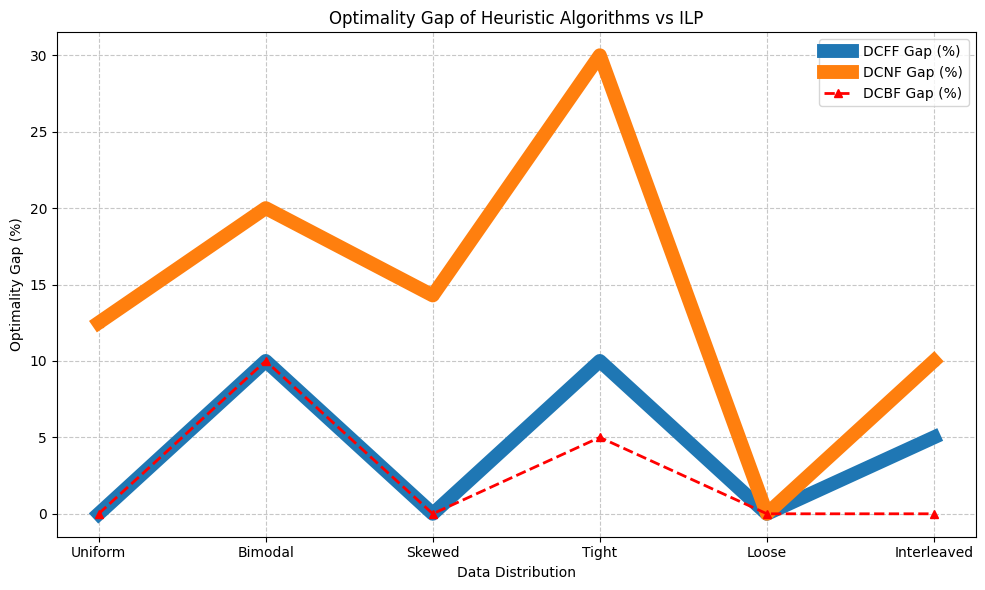

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data extracted directly from the console output log
data = {
    'Dataset': ['Uniform', 'Bimodal', 'Skewed', 'Tight', 'Loose', 'Interleaved'],
    'ILP Bins': [24, 20, 7, 20, 5, 20],
    'FFDD Bins': [24, 22, 7, 22, 5, 21],
    'NFD Bins': [27, 24, 8, 26, 5, 22],
    'DABF Bins': [24, 22, 7, 21, 5, 20]
}

df = pd.DataFrame(data)

# 2. Calculate the Optimality Gap as a percentage compared to ILP
df['FFDD Gap (%)'] = ((df['FFDD Bins'] - df['ILP Bins']) / df['ILP Bins']) * 100
df['NFD Gap (%)'] = ((df['NFD Bins'] - df['ILP Bins']) / df['ILP Bins']) * 100
df['DABF Gap (%)'] = ((df['DABF Bins'] - df['ILP Bins']) / df['ILP Bins']) * 100

# 3. Generate the Line Plot
plt.figure(figsize=(10, 6))

# Plot each heuristic's gap
plt.plot(df['Dataset'], df['FFDD Gap (%)'], marker='o', label='DCFF Gap (%)', linewidth=10)
plt.plot(df['Dataset'], df['NFD Gap (%)'], marker='s', label='DCNF Gap (%)', linewidth=10)

# Using a dashed line for DABF because its values overlap heavily with FFDD
plt.plot(df['Dataset'], df['DABF Gap (%)'], marker='^', label='DCBF Gap (%)', linestyle='--', linewidth=2, color='red')

# Formatting
plt.title('Optimality Gap of Heuristic Algorithms vs ILP')
plt.xlabel('Data Distribution')
plt.ylabel('Optimality Gap (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

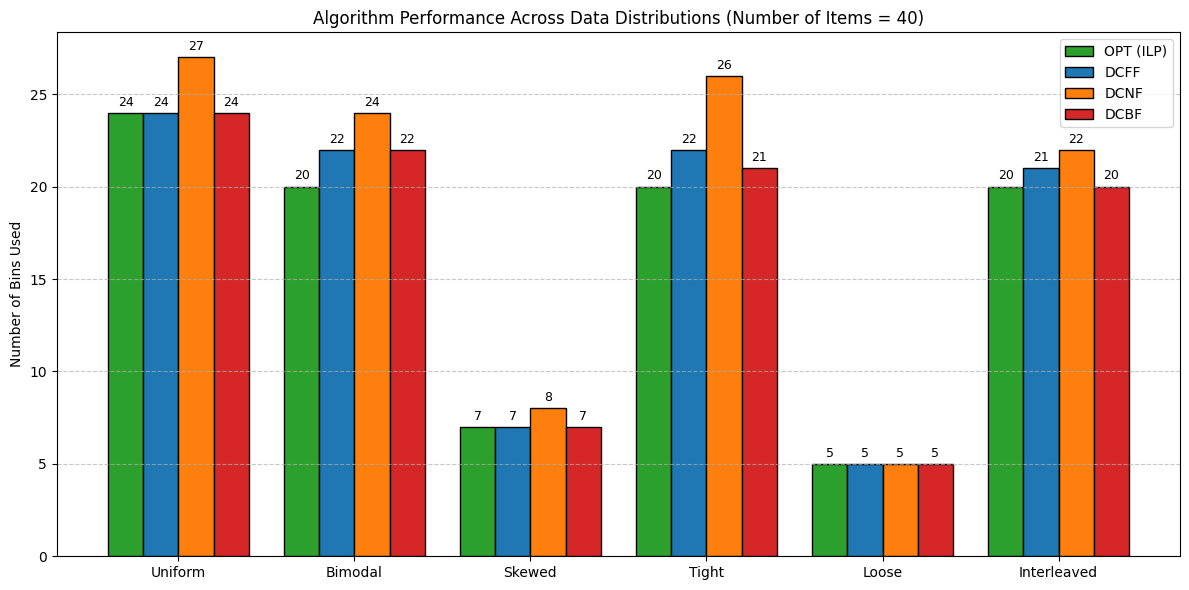

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# Plot 1: Heuristic Comparison Across Distributions (Grouped Bar Chart)
# =====================================================================

# Data extracted from previous ILP vs Heuristics logs
datasets = ['Uniform', 'Bimodal', 'Skewed', 'Tight', 'Loose', 'Interleaved']
x = np.arange(len(datasets))  # Label locations
width = 0.2  # Width of the bars

# Number of bins used by each algorithm
ilp_bins = [24, 20, 7, 20, 5, 20]
dcff_bins = [24, 22, 7, 22, 5, 21]
dcnf_bins = [27, 24, 8, 26, 5, 22]
dcbf_bins = [24, 22, 7, 21, 5, 20]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Create grouped bars
rects1 = ax1.bar(x - 1.5*width, ilp_bins, width, label='OPT (ILP)', color='#2ca02c', edgecolor='black')
rects2 = ax1.bar(x - 0.5*width, dcff_bins, width, label='DCFF', color='#1f77b4', edgecolor='black')
rects3 = ax1.bar(x + 0.5*width, dcnf_bins, width, label='DCNF', color='#ff7f0e', edgecolor='black')
rects4 = ax1.bar(x + 1.5*width, dcbf_bins, width, label='DCBF', color='#d62728', edgecolor='black')

# Formatting Plot 1
ax1.set_ylabel('Number of Bins Used')
ax1.set_title('Algorithm Performance Across Data Distributions (Number of Items = 40)')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax1.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.savefig('algorithm_comparison_barchart.png', dpi=300)
plt.show()




In [6]:
import numpy as np
import pandas as pd
import time
import pulp

# ==========================================
# 1. DATA GENERATION
# ==========================================


def generate_deadline_bin_packing_data(n_items, capacity):
    np.random.seed(42)
    
    # ==========================================
    # 1. Standard Random Distributions
    # ==========================================
    arrival_times = np.sort(np.random.randint(0, 50, n_items))
    deadlines = arrival_times + np.random.randint(20, 100, n_items)
    
    s1 = np.random.normal(capacity * 0.2, 5, n_items // 2)
    s2 = np.random.normal(capacity * 0.7, 5, n_items // 2)
    
    distributions = {
        'uniform': np.random.randint(1, capacity, n_items),
        'bimodal': np.clip(np.concatenate([s1, s2]), 1, capacity - 1),
        'skewed': (np.random.beta(a=1, b=5, size=n_items) * capacity).clip(1, capacity - 1),
        'tight': np.random.randint(capacity * 0.4, capacity * 0.6, n_items),
        'loose': np.random.randint(1, capacity * 0.2, n_items)
    }
    
    dataset = {}
    for dist_name, sizes in distributions.items():
        df = pd.DataFrame({
            'item_id': range(n_items),
            'size': sizes.astype(int),
            'arrival_time': arrival_times,
            'deadline': deadlines
        })
        dataset[dist_name] = df
        
    # ==========================================
    # 2. Adversarial Dataset (FF vs DABF)
    # ==========================================
    # We repeat the sequence [50, 70, 20, 40] to continuously trick FF.
    adv_sizes = []
    for _ in range(n_items // 4):
        adv_sizes.extend([50, 70, 20, 40])
        
    # Pad the remainder if n_items is not a perfect multiple of 4
    if n_items % 4 != 0:
        adv_sizes.extend([50, 70, 20, 40][:n_items % 4])
        
    adv_df = pd.DataFrame({
        'item_id': range(n_items),
        'size': adv_sizes,
        # Set arrivals to 0 to remove temporal interference and isolate spatial logic
        'arrival_time': np.zeros(n_items, dtype=int), 
        # Strictly increasing deadlines guarantee the algorithms sort and 
        # process the items in the exact adversarial order we built above.
        'deadline': np.arange(10, 10 + n_items * 10, 10) 
    })
    
    dataset['interleaved'] = adv_df
        
    return dataset

# ==========================================
# HELPER FUNCTION TO CALCULATE WASTE RATE
# ==========================================
def calculate_waste_rate(bins, df, capacity):
    """
    Calculates the proportion of total bin capacity that remains unused.
    Waste Rate = (Total Provisioned Capacity - Total Used Capacity) / Total Provisioned Capacity
    """
    if not bins:
        return 0.0  # If no bins were opened, no capacity was wasted
        
    # Total capacity is the number of bins opened multiplied by the capacity per bin
    total_capacity = len(bins) * capacity
    
    # Map item IDs to their sizes
    sizes = df.set_index('item_id')['size'].to_dict()
    
    used_capacity = 0
    for b in bins:
        bin_items = b.get('items', [])
        # Sum the sizes of all items placed in this bin
        used_capacity += sum(sizes[i] for i in bin_items)
            
    # The waste rate is the fraction of the total capacity that is empty
    waste_rate = (total_capacity - used_capacity) / total_capacity
    
    return waste_rate


# ==========================================
# 3. BIN PACKING ALGORITHMS
# ==========================================


# 2. Deadline-Aware First Fit
def ffdd_offline(df_items, capacity):
    sorted_items = df_items.sort_values(by=['deadline', 'size'], ascending=[True, False]).to_dict('records')
    bins = []
    for item in sorted_items:
        placed = False
        for b in bins:
            temporal_valid = item['arrival_time'] <= b['earliest_deadline']
            if b['remaining_capacity'] >= item['size'] and temporal_valid:
                b['items'].append(item['item_id'])
                b['remaining_capacity'] -= item['size']
                b['earliest_deadline'] = min(b['earliest_deadline'], item['deadline'])
                placed = True
                break
        if not placed:
            bins.append({
                'items': [item['item_id']],
                'remaining_capacity': capacity - item['size'],
                'earliest_deadline': item['deadline']
            })
    return bins

# 3. Deadline-Aware Next Fit (Online)
def next_fit_online(df_items, capacity):
    stream_items = df_items.sort_values(by=['arrival_time']).to_dict('records')
    bins = []
    for item in stream_items:
        placed = False
        if bins:
            current_bin = bins[-1]
            if current_bin['remaining_capacity'] >= item['size'] and item['arrival_time'] <= current_bin['earliest_deadline']:
                current_bin['items'].append(item['item_id'])
                current_bin['remaining_capacity'] -= item['size']
                current_bin['earliest_deadline'] = min(current_bin['earliest_deadline'], item['deadline'])
                placed = True
        if not placed:
            bins.append({
                'items': [item['item_id']],
                'remaining_capacity': capacity - item['size'],
                'earliest_deadline': item['deadline']
            })
    return bins

# 4. NEW: Deadline-Aware Best Fit (DABF)
def deadline_aware_best_fit(df_items, capacity):
    sorted_items = df_items.sort_values(by=['deadline', 'size'], ascending=[True, False]).to_dict('records')
    bins = []
    
    for item in sorted_items:
        best_bin_idx = -1
        min_remaining_space = float('inf')
        
        for i, b in enumerate(bins):
            temporal_valid = item['arrival_time'] <= b['earliest_deadline']
            spatial_valid = b['remaining_capacity'] >= item['size']
            
            if temporal_valid and spatial_valid:
                space_left = b['remaining_capacity'] - item['size']
                
                if space_left < min_remaining_space:
                    min_remaining_space = space_left
                    best_bin_idx = i
                    
        if best_bin_idx != -1:
            b = bins[best_bin_idx]
            b['items'].append(item['item_id'])
            b['remaining_capacity'] -= item['size']
            b['earliest_deadline'] = min(b['earliest_deadline'], item['deadline'])
        else:
            bins.append({
                'items': [item['item_id']],
                'remaining_capacity': capacity - item['size'],
                'earliest_deadline': item['deadline']
            })
            
    return bins

# ==========================================
# 4. EVALUATION
# ==========================================
def evaluate_heuristics(dataset, capacity=100):
    results = []
    
    for dist_name, df in dataset.items():
        
    
        # FFDD
        t0 = time.perf_counter()
        ffdd_bins = ffdd_offline(df, capacity)
        t_ffdd = time.perf_counter() - t0
        ffdd_waste = calculate_waste_rate(ffdd_bins, df, capacity)
        
        # Next Fit
        t0 = time.perf_counter()
        nf_bins = next_fit_online(df, capacity)
        t_nf = time.perf_counter() - t0
        nf_waste = calculate_waste_rate(nf_bins, df, capacity)
        
        # Best Fit
        t0 = time.perf_counter()
        dabf_bins = deadline_aware_best_fit(df, capacity)
        t_dabf = time.perf_counter() - t0
        dabf_waste = calculate_waste_rate(dabf_bins, df, capacity)
        
        results.append({
            'Dataset': dist_name.capitalize(),
            'FFDD Bins': len(ffdd_bins),
            'FFDD Waste%': round(ffdd_waste * 100, 2),
            'FFDD Time(s)': round(t_ffdd, 5),
            
            'NFD Bins': len(nf_bins),
            'NFD Waste%': round(nf_waste * 100, 2),
            'NFD Time(s)': round(t_nf, 5),
            
            'DABF Bins': len(dabf_bins),
            'DABF Waste%': round(dabf_waste * 100, 2),
            'DABF Time(s)': round(t_dabf, 5)
        })
        
    return pd.DataFrame(results)

if __name__ == "__main__":
    # Generated 10 items for a quick run, adjust `n_items` as needed
    data = generate_deadline_bin_packing_data(n_items=10000, capacity=100)
    df_results = evaluate_heuristics(data, capacity=100)
    
    print("\n" + "="*100)
    print("HEURISTIC ALGORITHMS COMPARISON: DCFF vs DCNF vs DCBF")
    print("="*100)
    print(df_results.to_string(index=False))


HEURISTIC ALGORITHMS COMPARISON: DCFF vs DCNF vs DCBF
    Dataset  FFDD Bins  FFDD Waste%  FFDD Time(s)  NFD Bins  NFD Waste%  NFD Time(s)  DABF Bins  DABF Waste%  DABF Time(s)
    Uniform       5075         1.81       1.54123      6661       25.19      0.05167       5049         1.31       2.18134
    Bimodal       5260        15.26       1.31642      6088       26.78      0.00970       5260        15.26       2.20526
     Skewed       1639         0.02       0.65459      1907       14.07      0.01094       1639         0.02       0.88379
      Tight       5003         1.29       2.06273      6678       26.05      0.01303       5003         1.29       3.35572
      Loose       1001         0.06       0.48660      1063        5.89      0.01483       1001         0.06       0.63553
Interleaved       5001        10.02       2.13402      5381       16.37      0.01231       5000        10.00       3.27822
